# Read coordinates

In [18]:
from wings.detection.dataset import collect_image_paths
from wings.config import RAW_DATA_DIR, COUNTRIES, IMG_FOLDER_SUFX, COORDS_SUFX

image_paths = collect_image_paths(RAW_DATA_DIR, COUNTRIES)



2026-04-23 12:02:51.263 | INFO     | wings.detection.dataset:collect_image_paths:30 - Collecting image paths from: C:\Users\X\projects\bees\data\raw


C:\Users\X\projects\bees\data\raw\PL-wing-images\PL-0137-000868-L.dw.png
[190 170 212 168 263 250 271 199 269 112 332 252 390 286 370 263 415 231
 375 207 417 180 420 137 436 106 453 276 494 239 569 202 603 199 612 174
  76 247]


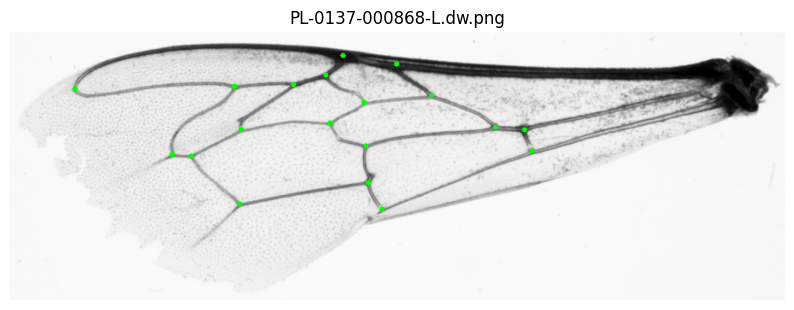

In [ ]:

import random
import cv2
import matplotlib.pyplot as plt
import pandas as pd

sample_path = random.choice(image_paths)
print(sample_path)

img = cv2.imread(str(sample_path))
if img is None:
    raise FileNotFoundError(f"Could not read image: {sample_path}")


filename = sample_path.name
country = filename.split('-', 1)[0]

df = pd.read_csv(RAW_DATA_DIR / f"{country}{COORDS_SUFX}")
row = df[df['file'] == filename].iloc[0]

targets = pd.to_numeric(row.iloc[1:].values)
print(targets)

x_coords, y_coords = targets[::2], targets[1::2]
y_size = img.shape[0]
y_coords = y_size - y_coords - 1
for x, y in zip(x_coords, y_coords):
    x, y = int(x), int(y)
    cv2.circle(img, (x, y), 3, (0, 255, 0), -1)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title(f"{sample_path.name}")
plt.axis("off")
plt.show()

In [97]:
from pathlib import Path
import numpy as np


def read_coordinates(filepath: Path, img: np.ndarray):
    filename = filepath.name
    country = filename.split('-', 1)[0]

    df = pd.read_csv(RAW_DATA_DIR / f"{country}{COORDS_SUFX}")
    row = df[df['file'] == filename].iloc[0]

    targets = pd.to_numeric(row.iloc[1:].values)

    x_coords, y_coords = targets[::2], targets[1::2]
    y_size = img.shape[0]
    y_coords = y_size - y_coords - 1

    return x_coords, y_coords


def process_bbox(x_coords, y_coords, img, x_factor = 1.2, y_factor = 1.4):
    x_min, x_max = x_coords.min(), x_coords.max()
    y_min, y_max = y_coords.min(), y_coords.max()

    cx = (x_min + x_max) / 2
    cy = (y_min + y_max) / 2

    w = (x_max - x_min) * x_factor
    h = (y_max - y_min) * y_factor

    x_size, y_size = img.shape[1], img.shape[0]

    cx = round(cx / x_size, 6)
    cy = round(cy / y_size, 6)
    w = round(w / x_size, 6)
    h = round(h / y_size, 6)

    return [ 0, cx, cy, w, h]



# Test bounding box

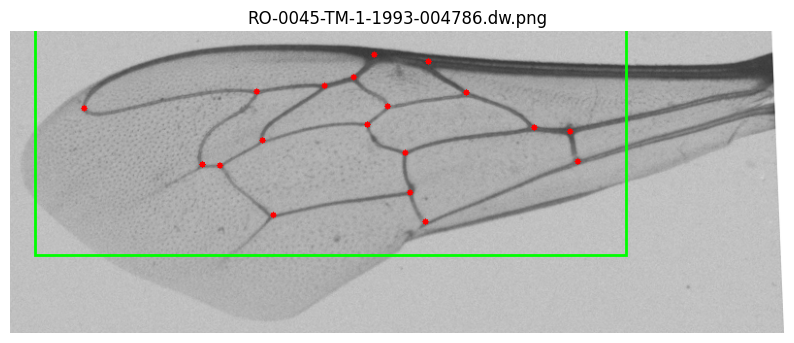

In [106]:
import matplotlib.patches as patches

sample_path = random.choice(image_paths)

img_bgr = cv2.imread(str(sample_path))

x_coords, y_coords = read_coordinates(sample_path, img_bgr)
bbox = process_bbox(x_coords, y_coords, img_bgr)

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# YOLO box format: [class_id, cx, cy, bw, bh] (normalized)
class_id, cx, cy, bw, bh = bbox
x1 = int((cx - bw / 2) * w)
y1 = int((cy - bh / 2) * h)
box_w = int(bw * w)
box_h = int(bh * h)

for x, y in zip(x_coords, y_coords):
    x, y = int(x), int(y)
    cv2.circle(img, (x, y), 3, (255, 0, 0), -1)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)
ax.add_patch(
    patches.Rectangle(
        (x1, y1),
        box_w,
        box_h,
        linewidth=2,
        edgecolor="lime",
        facecolor="none",
    )
)
ax.set_title(f"{sample_path.name}")
ax.axis("off")
plt.show()

# Bounding boxes on images with extra padding

(352, 568, 515, 570)


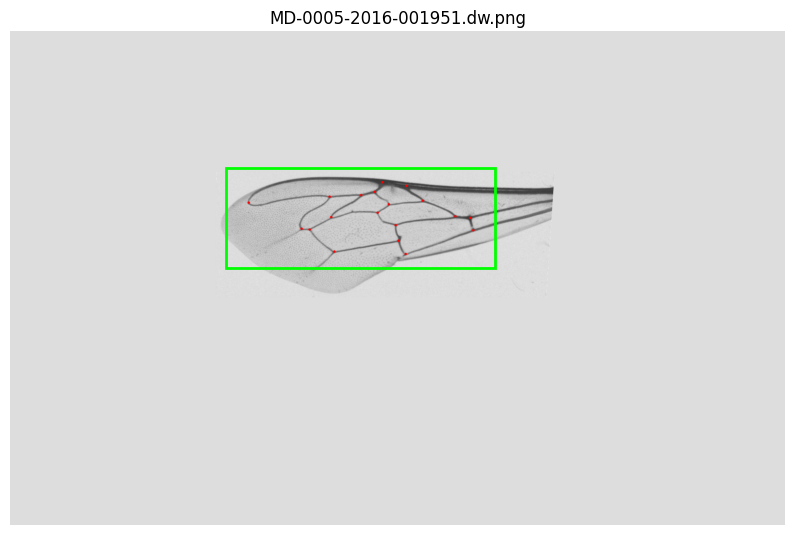

In [222]:
import matplotlib.patches as patches
from wings.detection.dataset import pad_image

sample_path = random.choice(image_paths)

img_bgr = cv2.imread(str(sample_path))

x_coords, y_coords = read_coordinates(sample_path, img_bgr)

pad_values = tuple(np.random.randint(100, 600) for _ in range(4))
# pad_values = (0, 0, 100, 0)
padded = pad_image(img_bgr, pad_values)

print(pad_values)

x_coords = x_coords + pad_values[2]
y_coords = y_coords + pad_values[0]

bbox = process_bbox(x_coords, y_coords, padded)

img = cv2.cvtColor(padded, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# YOLO box format: [class_id, cx, cy, bw, bh] (normalized)
class_id, cx, cy, bw, bh = bbox
x1 = int((cx - bw / 2) * w)
y1 = int((cy - bh / 2) * h)
box_w = int(bw * w)
box_h = int(bh * h)

for x, y in zip(x_coords, y_coords):
    x, y = int(x), int(y)
    cv2.circle(img, (x, y), 3, (255, 0, 0), -1)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)
ax.add_patch(
    patches.Rectangle(
        (x1, y1),
        box_w,
        box_h,
        linewidth=2,
        edgecolor="lime",
        facecolor="none",
    )
)
ax.set_title(f"{sample_path.name}")
ax.axis("off")
plt.show()

# Test dataset

In [223]:
import json
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from wings.config import PROCESSED_DATA_DIR

dataset_folder = PROCESSED_DATA_DIR / "detection"
dataset_path = dataset_folder / "dataset.ndjson"

image_records = []
with dataset_path.open("r", encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)
        if rec.get("type") == "image" and rec.get("annotations", {}).get("boxes"):
            image_records.append(rec)


len(image_records)

21722

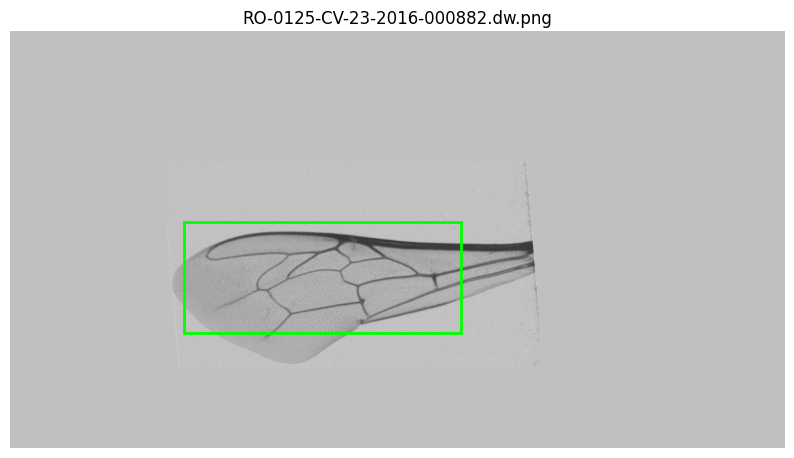

In [274]:
sample = random.choice(image_records)

img_path = dataset_folder / Path(sample["file"])
img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"Could not read image: {img_path}")

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# YOLO box format: [class_id, cx, cy, bw, bh] (normalized)
class_id, cx, cy, bw, bh = sample["annotations"]["boxes"][0]
x1 = int((cx - bw / 2) * w)
y1 = int((cy - bh / 2) * h)
box_w = int(bw * w)
box_h = int(bh * h)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)
ax.add_patch(
    patches.Rectangle(
        (x1, y1),
        box_w,
        box_h,
        linewidth=2,
        edgecolor="lime",
        facecolor="none",
    )
)
ax.set_title(f"{img_path.name}")
ax.axis("off")
plt.show()